In [103]:
# warnings
import warnings
warnings.filterwarnings('ignore')

In [104]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
pallete = 'ch:start=.2,rot=-.3'

### Reading Data

In [106]:
data = pd.read_csv('data.csv')
data.drop(columns=['ID'], inplace=True)
data.columns = data.columns.str.replace('_', ' ').str.replace('.', '_').str.title().str.strip().str.replace(' ', '_')

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_Block      10999 non-null  object 
 1   Mode_Of_Shipment     10999 non-null  object 
 2   Customer_Care_Calls  10999 non-null  int64  
 3   Customer_Rating      10999 non-null  int64  
 4   Cost_Of_The_Product  10901 non-null  float64
 5   Prior_Purchases      10999 non-null  int64  
 6   Product_Importance   10845 non-null  object 
 7   Gender               10999 non-null  object 
 8   Discount_Offered     10999 non-null  int64  
 9   Weight_In_Gms        10860 non-null  float64
 10  Reached_On_Time_Y_N  10999 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 945.4+ KB


Missing value imputation

In [108]:
data.isna().sum()

Warehouse_Block          0
Mode_Of_Shipment         0
Customer_Care_Calls      0
Customer_Rating          0
Cost_Of_The_Product     98
Prior_Purchases          0
Product_Importance     154
Gender                   0
Discount_Offered         0
Weight_In_Gms          139
Reached_On_Time_Y_N      0
dtype: int64

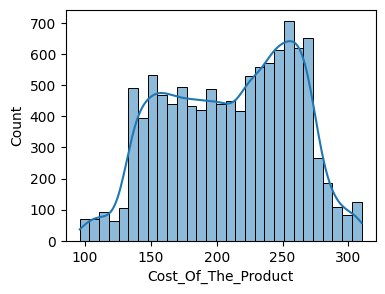

In [109]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Cost_Of_The_Product', kde=True, fill=True)
plt.show()

In [110]:
data.Cost_Of_The_Product.fillna(data.Cost_Of_The_Product.median(), inplace=True)

In [111]:
data.Product_Importance.fillna(data.Product_Importance.mode()[0], inplace=True)

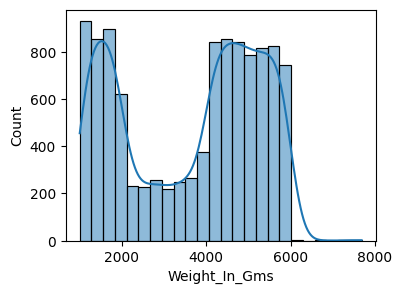

In [112]:
fig = plt.figure(figsize=(4,3))
sns.histplot(data=data, x='Weight_In_Gms', kde=True, fill=True)
plt.show()

In [113]:
data.Weight_In_Gms.fillna(data.Weight_In_Gms.median(), inplace=True)

### Exploring Data

Exploring Categorical Variables

In [114]:
categorical_variables = ['Warehouse_Block', 'Mode_Of_Shipment', 'Product_Importance', 'Gender']

Warehouse Block

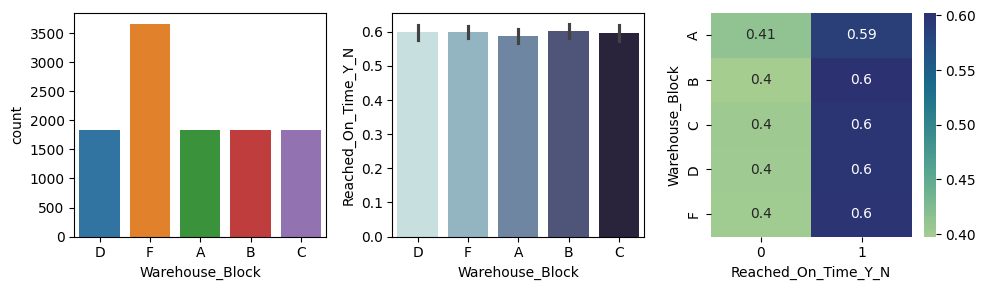

In [115]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Warehouse_Block', hue='Warehouse_Block')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Warehouse_Block', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Warehouse_Block, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Mode Of Shipment

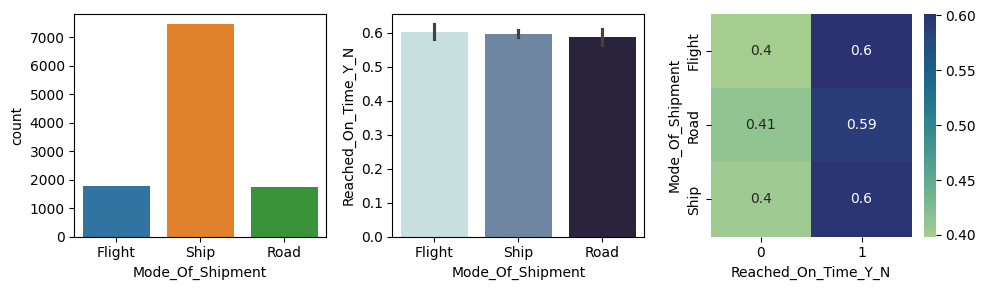

In [116]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Mode_Of_Shipment', hue='Mode_Of_Shipment')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Mode_Of_Shipment', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Mode_Of_Shipment, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='crest')
plt.tight_layout()
plt.show()

Product Importance

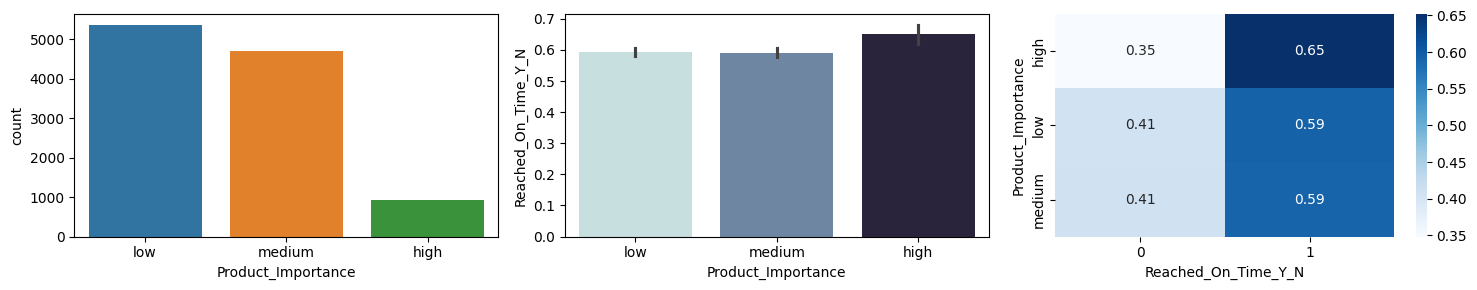

In [117]:
fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Product_Importance', hue='Product_Importance')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Product_Importance', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Product_Importance, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Gender

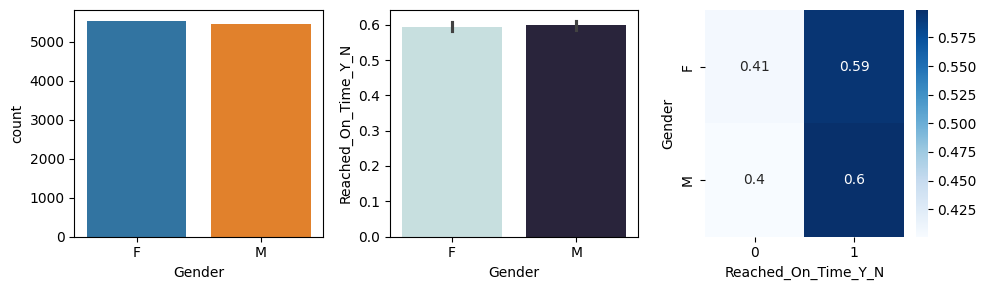

In [118]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Gender', hue='Gender')
plt.subplot(1, 3, 2)
sns.barplot(data=data, x='Gender', y='Reached_On_Time_Y_N', palette=pallete)
plt.subplot(1, 3, 3)
sns.heatmap(pd.crosstab(data.Gender, data.Reached_On_Time_Y_N, normalize='index'), annot=True, cmap='Blues')
plt.tight_layout()
plt.show()

Exploring Numerical Variables

In [119]:
numerical_columns = ['Customer_Care_Calls', 'Customer_Rating', 'Cost_Of_The_Product', 'Prior_Purchases', 'Discount_Offered', 'Weight_In_Gms', 'Reached_On_Time_Y_N']

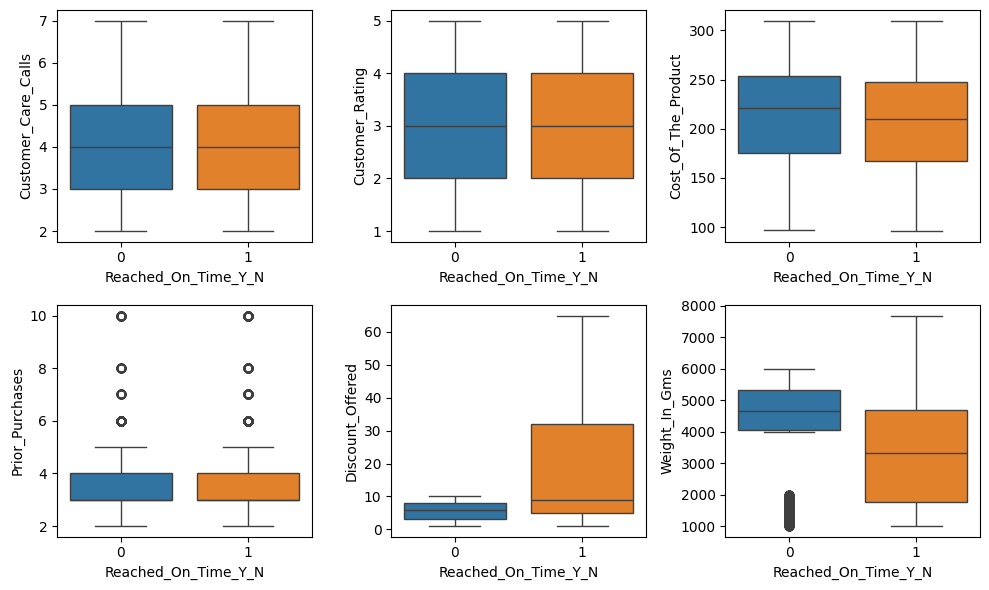

In [120]:
fig = plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
sns.boxplot(data=data, y='Customer_Care_Calls', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 2)
sns.boxplot(data=data, y='Customer_Rating', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 3)
sns.boxplot(data=data, y='Cost_Of_The_Product', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 4)
sns.boxplot(data=data, y='Prior_Purchases', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 5)
sns.boxplot(data=data, y='Discount_Offered', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.subplot(2, 3, 6)
sns.boxplot(data=data, y='Weight_In_Gms', x='Reached_On_Time_Y_N', hue='Reached_On_Time_Y_N', legend=False)
plt.tight_layout()
plt.show()

In [121]:
# Features showing relationshipt with state of shipment
# Cost of product
# Discount
# Weight

Correlation

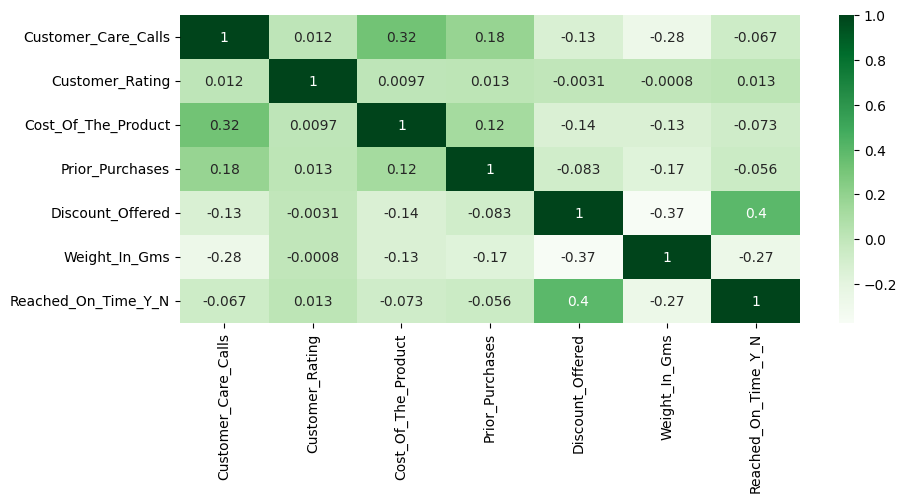

In [122]:
fig = plt.figure(figsize=(10, 4))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='Greens')
plt.show()

Creating Features

In [123]:
categorical_variables.remove('Gender')

In [124]:
featured_data = pd.get_dummies(data=data, columns=categorical_variables).replace({True: 1, False: 0})

Gender

In [125]:
gender_map = {'M': 1, 'F': 0}
featured_data.Gender = featured_data.Gender.map(gender_map)

In [126]:
numerical_features = list(numerical_columns)
numerical_features.remove('Reached_On_Time_Y_N')

Splitting Data

In [127]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(featured_data, train_size=0.6, test_size=0.4, random_state=42)
y_train = X_train.pop('Reached_On_Time_Y_N')
y_test = X_test.pop('Reached_On_Time_Y_N')

Scaling Data

In [128]:
from sklearn.preprocessing import MinMaxScaler

In [129]:
scaler = MinMaxScaler()

In [130]:
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [131]:
X_train.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Discount_Offered,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000,6599.000000
mean,0.417427,0.496818,0.538292,0.200636,0.501137,0.190408,0.397836,0.165480,0.163964,0.166086,0.170935,0.333535,0.166843,0.158357,0.674799,0.083801,0.489923,0.426277
std,0.230567,0.352062,0.224788,0.192838,0.500037,0.250791,0.245573,0.371641,0.370271,0.372186,0.376481,0.471512,0.372864,0.365103,0.468485,0.277110,0.499936,0.494572
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.350467,0.125000,0.000000,0.046875,0.127052,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.560748,0.125000,1.000000,0.093750,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.724299,0.250000,1.000000,0.140625,0.608074,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [132]:
X_test.describe()

,Customer_Care_Calls,Customer_Rating,Cost_Of_The_Product,Prior_Purchases,Gender,Discount_Offered,Weight_In_Gms,Warehouse_Block_A,Warehouse_Block_B,Warehouse_Block_C,Warehouse_Block_D,Warehouse_Block_F,Mode_Of_Shipment_Flight,Mode_Of_Shipment_Road,Mode_Of_Shipment_Ship,Product_Importance_high,Product_Importance_low,Product_Importance_medium
count,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000,4400.000000
mean,0.401091,0.498864,0.527006,0.188920,0.487955,0.197717,0.400077,0.168409,0.170682,0.167500,0.160455,0.332955,0.153636,0.162500,0.683864,0.085682,0.485909,0.428409
std,0.224522,0.355435,0.221658,0.186376,0.499912,0.256764,0.243849,0.374272,0.376273,0.373464,0.367069,0.471324,0.360641,0.368951,0.465020,0.279925,0.499858,0.494904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.250000,0.341121,0.125000,0.000000,0.046875,0.130705,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.500000,0.542056,0.125000,0.000000,0.093750,0.475448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.600000,0.750000,0.714953,0.250000,1.000000,0.140625,0.610484,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.006628,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Data Imbalance

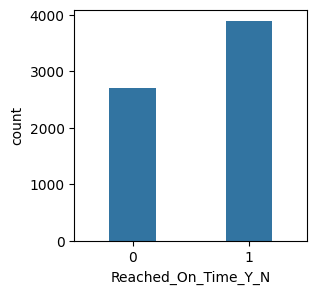

Reached_On_Time_Y_N
1    3901
0    2698
Name: count, dtype: int64

In [133]:
fig = plt.figure(figsize=(3, 3))
sns.barplot(y_train.value_counts(), width=0.4)
plt.show()
y_train.value_counts()

### Training & Evaluating Model

Training Model

In [134]:
from sklearn.neighbors import KNeighborsClassifier

In [135]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [136]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Evaluating Model

In [137]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

In [138]:
predictions = knn_model.predict(X_test)

In [139]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53      1738
           1       0.69      0.66      0.68      2662

    accuracy                           0.62      4400
   macro avg       0.60      0.61      0.61      4400
weighted avg       0.62      0.62      0.62      4400



In [140]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)

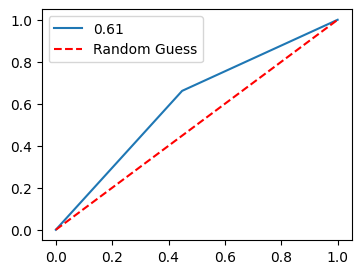

In [141]:
fig = plt.figure(figsize=(4, 3))
sns.lineplot(x=fpr, y=tpr, label=f"{roc_auc_score(y_test, predictions):.2f}")
sns.lineplot(x=[0,1], y=[0,1], linestyle='--', color='red', label='Random Guess')
plt.show()

### Optimal Value Of K

In [142]:
from sklearn.model_selection import cross_val_score

In [143]:
k_values = list(range(1, 21))
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

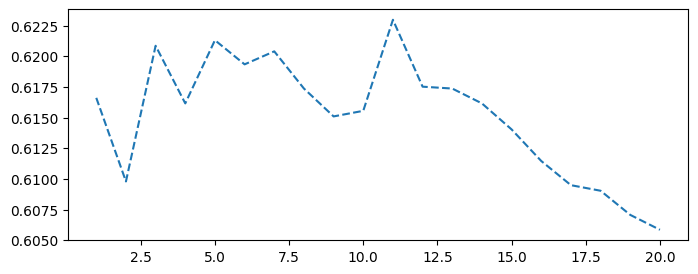

In [144]:
fig = plt.figure(figsize=(8, 3))
sns.lineplot(x=k_values, y=cv_scores, linestyle='--', markers=['x'])
plt.show()

In [145]:
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal value for k: {optimal_k}")

Optimal value for k: 11


### Hyper-Parameter tuning

In [146]:
from sklearn.model_selection import GridSearchCV

In [147]:
neighbour = list(range(3, 12, 2))
weight = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

In [148]:
parameter_grid = {
    'n_neighbors': neighbour,
    'weights': weight,
    'metric': metric
}

In [149]:
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid=parameter_grid, cv=5, scoring='accuracy')

In [150]:
grid_search.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [151]:
knn_model_b = grid_search.best_estimator_

In [152]:
y_pred = knn_model_b.predict(X_test)

Evaluating Best Model

In [153]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.60      0.56      1738
           1       0.71      0.64      0.67      2662

    accuracy                           0.62      4400
   macro avg       0.62      0.62      0.62      4400
weighted avg       0.63      0.62      0.63      4400

